In [1]:
import os
import torch
import numpy as np, pandas as pd, random
import itertools
from time import time, sleep
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt, seaborn as sns

import sklearn
from sklearn.frozen import FrozenEstimator
from sklearn.calibration import CalibratedClassifierCV
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import balanced_accuracy_score, log_loss
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split
from sklearn.preprocessing import TargetEncoder, KBinsDiscretizer, label_binarize

import warnings
warnings.simplefilter('ignore')
warnings.filterwarnings('ignore')

In [2]:
try:
    from tabpfn import TabPFNClassifier
except:
    %pip install -q -U tabpfn
    from tabpfn import TabPFNClassifier

# !pip show tabpfn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 727.9/727.9 kB 13.9 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [3]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
secret_token = user_secrets.get_secret("pfn_key")

# secret_token = "tabpfn_sk_BRazYGiNBKYBWNHuuOmOJUvMiqzHsLQLlPrRQMsBQ8Q"

RUN_LOCAL_MODEL = True
USE_PFN_TOKEN   = True

if RUN_LOCAL_MODEL:
    print("Loading tabpfn_local... ", end='')
    try:
        from tabpfn import TabPFNClassifier
    except:
        %pip install -q -U tabpfn
        from tabpfn import TabPFNClassifier
    ## -----------------------------------------------------
    if USE_PFN_TOKEN: # Option 1: Use secret token key
        os.environ["TABPFN_TOKEN"] = secret_token
    else: # Option 2: Access to direct model
        os.environ["TABPFN_MODEL_CACHE_DIR"] = "/kaggle/input/models/prior-labsai/tabpfn-3/pytorch/default/1"
    print("Complete!")
else:
    print("Connecting tabpfn_client... ", end='')
    try:
        import tabpfn_client
        from tabpfn_client import TabPFNClassifier, set_access_token
    except:
        %pip install -q -U tabpfn-client
        import tabpfn_client
        from tabpfn_client import TabPFNClassifier, set_access_token

    tabpfn_client.set_access_token(secret_token)
    print("Complete!")

# secret_token

Loading tabpfn_local... Complete!


In [4]:
## -- Device-Agnostic (GPU/CPU) --
def get_system_info():
    if torch.cuda.is_available():
        return f"GPU: {torch.cuda.get_device_name(0)}"
    else:
        return f"CPU: {os.cpu_count()}"

get_system_info()

'GPU: Tesla T4'

In [5]:
## -- Global Settings --
# sklearn.set_config(transform_output="pandas")

# pd.options.mode.copy_on_write = True
pd.set_option('display.max_columns', 1000)
sns.set_style("whitegrid")
# plt.style.use("ggplot")

PALETTE = ['#3A86FF', '#F94144', '#FFBE0B', '#73D2DE', '#FBB13C']
sns.set_palette(PALETTE)

cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)

## -- Set Global Configuration --
CFG = {
    'FOLDS': 5,
    'SEED': 42,
    'GREEN': '\033[32m',
    'YELLOW': '\033[33m',
    'RESET': '\033[0m'
}

print(f"CLASSIC {CFG['GREEN']} GREEN {CFG['RESET']} {CFG['YELLOW']} YELLOW {CFG['RESET']}")

CLASSIC  GREEN   YELLOW 


In [6]:
def seed_everything(seed):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

seed_everything(seed=CFG['SEED'])

## Load Data

In [7]:
## -- ⚠️ IMPORTANT: SELECT PLATFORM ⚠️ --
PLATFORM = 'kaggle' # -> 'colab' 'kaggle'

if PLATFORM == 'kaggle':
    PATH = '/kaggle/input/competitions/playground-series-s6e7/'
    submit = pd.read_csv(PATH+'sample_submission.csv')
    train = pd.read_csv(PATH+'train.csv')
    test = pd.read_csv(PATH+'test.csv')

    ORIG_PATH = '/kaggle/input/datasets/ziya07/college-student-health-behavior-dataset/'
    orig = pd.read_csv(ORIG_PATH+'student_health_dataset_50k.csv')
elif PLATFORM == 'colab':
    from google.colab import drive
    drive.mount('/content/drive')

    PATH = '/content/drive/MyDrive/-- shared_notebooks --/Ps6e7 | Student Health/_student_health_data/'
    submit = pd.read_csv(PATH+'sample_submission.csv')
    train = pd.read_csv(PATH+'train.csv')
    test = pd.read_csv(PATH+'test.csv')
    orig = pd.read_csv(PATH+'student_health_dataset_50k.csv')

## =================================================================================

ID      = 'id'
TARGET  = 'health_condition'
OBJECTS = train.select_dtypes(include=['object', 'category']).columns.tolist()

CATS = [c for c in OBJECTS if c not in [TARGET, ID]]
NUMS = [c for c in train.columns if c not in CATS+[TARGET, ID]]
BASE = NUMS + CATS

NUM_CLASSES = train[TARGET].nunique()

## -- Fill categorical --
train[CATS] = train[CATS].fillna('missing')
test[CATS]  = test[CATS].fillna('missing')
orig[CATS]  = orig[CATS].fillna('missing')

# {c: i for i, c in enumerate(train[TARGET].unique())}
mapping   = {'fit': 0, 'at-risk': 1, 'unhealthy': 2}
r_mapping = {v: k for k, v in mapping.items()}

train[TARGET] = train[TARGET].map(mapping)
orig[TARGET]  = orig[TARGET].map(mapping)

for (name, df) in {'Train': train, 'Test': test, 'Orig': orig}.items():
    print(f"{name} shape: {df.shape}")

print(f"\nTotal Numerical: {len(NUMS)}")
print(f"Total Categorical: {len(CATS)}")
print(f"Total base features: {len(BASE)}")

Train shape: (690088, 15)
Test shape: (295753, 14)
Orig shape: (50000, 16)

Total Numerical: 7
Total Categorical: 6
Total base features: 13


In [8]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690088 entries, 0 to 690087
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       690088 non-null  int64  
 1   health_condition         690088 non-null  int64  
 2   sleep_duration           614089 non-null  float64
 3   heart_rate               682255 non-null  float64
 4   bmi                      676190 non-null  float64
 5   calorie_expenditure      637235 non-null  float64
 6   step_count               676172 non-null  float64
 7   exercise_duration        683187 non-null  float64
 8   water_intake             646611 non-null  float64
 9   diet_type                690088 non-null  object 
 10  stress_level             690088 non-null  object 
 11  sleep_quality            690088 non-null  object 
 12  physical_activity_level  690088 non-null  object 
 13  smoking_alcohol          690088 non-null  object 
 14  gend

## Preprocess Features

In [9]:
def get_weights(y, y_true, opt='auto'):
    """
    y: Current y labels -> numpy array or series
    y_true: True labels -> numpy array or series
    opt: 'auto' generate weight or pass a custom dict -> label: weight
    """
    if opt != 'auto':
        sample_weights = np.array([opt[label] for label in y])
        return sample_weights
    else:
        classes_ = np.unique(y_true)
        weights_ = compute_class_weight('balanced', classes=classes_, y=y_true)
        class_weights = dict(zip(classes_, weights_))
        sample_weights = np.array([class_weights[label] for label in y])
        return sample_weights

def balanced_acc(y_true, y_proba):
    pred_labels = np.argmax(y_proba, axis=1)
    return balanced_accuracy_score(y_true, pred_labels)

def multi_class_brier(y_true, y_proba, classes):
    y_onehot = label_binarize(y_true, classes=classes)
    return float(np.mean(np.sum((y_onehot - y_proba) ** 2, axis=1)))

def t_enc_multi(X_tr, X_va, X_ts, y_tr, cols, drop=False):
    X_tr_1 = X_tr.copy()
    X_va_1 = X_va.copy()
    X_ts_1 = X_ts.copy()

    te_enc = TargetEncoder(target_type='multiclass', random_state=CFG["SEED"]).set_output(transform='pandas')

    X_tr_te = te_enc.fit_transform(X_tr_1[cols], y_tr)
    X_va_te = te_enc.transform(X_va_1[cols])
    X_ts_te = te_enc.transform(X_ts_1[cols])

    te_names = [f"TE_{c}" for c in X_tr_te.columns]
    X_tr_1[te_names] = X_tr_te.astype('float32')
    X_va_1[te_names] = X_va_te.astype('float32')
    X_ts_1[te_names] = X_ts_te.astype('float32')

    if drop:
        X_tr_1 = X_tr_1.drop(columns=cols)
        X_va_1 = X_va_1.drop(columns=cols)
        X_ts_1 = X_ts_1.drop(columns=cols)

    return X_tr_1, X_va_1, X_ts_1

print("- Helper functions ready -")

- Helper functions ready -


In [10]:
# -- FE by @yekenot

X = train.drop(columns=[ID, TARGET]); train_id = train[ID]
y = train[TARGET]
X_test = test.drop(columns=[ID]); test_id = test[ID]

del train, test
print("X      init shape:", X.shape)
print("X_ts init shape:", X_test.shape, "\n")

cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = X.select_dtypes(exclude=['object']).columns.tolist()
print("init len(cat_cols):", len(cat_cols))
print("init len(num_cols):", len(num_cols), "\n")

category_map = {}
important_combos = [
    ('heart_rate', 'bmi'),
]
important_combos = sorted(important_combos)
def feature_engineering(df, fit=False):
    # Fill NaNs
    for col in cat_cols:
        df[col] = df[col].fillna("missing")
    for col in num_cols:
        df[col] = df[col].fillna(0.0)
    
    # Categorize string cats
    for col in cat_cols:
        if fit:
            codes, uniques = df[col].factorize()
            category_map[col] = uniques
        else:
            uniques = category_map[col]
            code_map = {cat: i for i, cat in enumerate(uniques)}
            codes = df[col].map(code_map).fillna(-1).astype('int32')
        df[col] = codes
        df[col] = df[col].astype('category')

    # Categorize numericals
    for col in num_cols:
        cat_name = f"{col}_cat_"

        if col == 'calorie_expenditure':
            df[cat_name] = (df[col] // 5).astype('int32').astype('category')
            continue

        if col == 'water_intake':
            df['water_intake_cat2_'] = (df[col] * 50).astype('int32').astype('category')

        round_level = -1
        if fit:
            round_flag = col == 'step_count'
            series = df[col].round(round_level) if round_flag else df[col]
            codes, uniques = series.factorize()
            category_map[col] = {'uniques': uniques, 'round_flag': round_flag}
        else:
            round_flag = category_map[col]['round_flag']
            uniques = category_map[col]['uniques']
            series = df[col].round(round_level) if round_flag else df[col]
            code_map = {cat: i for i, cat in enumerate(uniques)}
            codes = series.map(code_map).fillna(-1).astype('int32')
        df[cat_name] = codes    
        df[cat_name] = df[cat_name].astype('category')

    # Discretize numericals
    bin_config = {'sleep_duration': [70], 'water_intake': [10]}
    for col, bins_list in bin_config.items():
        for n_bins in bins_list:
            for strategy in ['quantile']:
                bin_name = f"{col}_{n_bins}_{strategy}_bin_"
                if fit:
                    kb = KBinsDiscretizer(
                        n_bins=n_bins,
                        encode='ordinal',
                        strategy=strategy,
                        subsample=None
                    )
                    binned = kb.fit_transform(df[[col]]).ravel().astype('int32')
                    category_map[bin_name] = kb
                else:
                    kb = category_map[bin_name]
                    binned = kb.transform(df[[col]]).ravel().astype('int32')
                df[bin_name] = binned
                df[bin_name] = df[bin_name].astype('category')

    # Create interaction categories
    combo_names = []
    for cols in important_combos:
        combo_name = '_'.join(cols) + '_'
        combo_names.append(combo_name)
        combo_series = df[cols[0]].astype(str)
        for col in cols[1:]:
            combo_series = combo_series + '_' + df[col].astype(str)
        if fit:
            codes, uniques = pd.factorize(combo_series, sort=False)
            category_map[combo_name] = uniques
        else:
            uniques = category_map[combo_name]
            code_map = {cat: i for i, cat in enumerate(uniques)}
            codes = combo_series.map(code_map).fillna(-1).astype('int32')
        df[combo_name] = codes
        df[combo_name] = df[combo_name].astype('category')    

    new_cat_cols = [col for col in df.columns if col.endswith('_')]
    new_num_cols = [col for col in df.columns if col.startswith('_')]
    return df, new_cat_cols, new_num_cols

X, new_cat_cols, new_num_cols = feature_engineering(X, fit=True)
X_test, new_cat_cols, new_num_cols = feature_engineering(X_test, fit=False)
cat_cols += new_cat_cols; num_cols += new_num_cols
print("len(new_cat_cols):", len(new_cat_cols))
print("len(new_num_cols):", len(new_num_cols), "\n")

cat_cols = sorted(cat_cols)
X = X.reindex(sorted(X.columns), axis=1)
X_test = X_test.reindex(sorted(X_test.columns), axis=1)
print("prep len(cat_cols):", len(cat_cols))
print("prep len(num_cols):", len(num_cols), "\n")
print("X      prep shape:", X.shape)
print("X_test prep shape:", X_test.shape, "\n")

X      init shape: (690088, 13)
X_ts init shape: (295753, 13) 

init len(cat_cols): 6
init len(num_cols): 7 

len(new_cat_cols): 11
len(new_num_cols): 0 

prep len(cat_cols): 17
prep len(num_cols): 7 

X      prep shape: (690088, 24)
X_test prep shape: (295753, 24) 



In [11]:
combined = pd.concat([X, X_test])

for c in cat_cols:
    combined[c] = combined[c].astype(str)

X = combined[:len(X)]
X_test = combined[len(X):len(X)+len(X_test)]

## -- Get categorical indices --
cat_idx = [[*X.columns].index(f) for f in cat_cols]
print(f"Categorical indices: {cat_idx }")

del combined

Categorical indices: [1, 3, 4, 6, 7, 9, 10, 11, 13, 14, 15, 16, 18, 19, 21, 22, 23]


In [12]:
X.head()

,bmi,bmi_cat_,calorie_expenditure,calorie_expenditure_cat_,diet_type,exercise_duration,exercise_duration_cat_,gender,heart_rate,heart_rate_bmi_,heart_rate_cat_,physical_activity_level,sleep_duration,sleep_duration_70_quantile_bin_,sleep_duration_cat_,sleep_quality,smoking_alcohol,step_count,step_count_cat_,stress_level,water_intake,water_intake_10_quantile_bin_,water_intake_cat2_,water_intake_cat_
0,25.66,0,2174.0,434,0,19.8,0,0,70.6,0,0,0,5.22,5,0,0,0,1326.0,0,0,1.86,3,93,0
1,25.84,1,1966.0,393,1,49.9,1,1,71.3,1,1,1,5.53,7,1,0,0,9891.0,1,1,1.26,0,63,1
2,24.54,2,2688.0,537,0,38.1,2,2,75.4,2,2,2,5.29,5,2,1,0,14216.0,2,0,1.60,1,80,2
3,23.13,3,2630.0,526,0,59.9,3,0,77.2,3,3,2,4.70,2,3,0,1,7174.0,3,0,2.02,4,101,3
4,28.44,4,2560.0,512,0,46.0,4,2,73.4,4,4,0,7.23,37,4,0,2,6584.0,4,2,2.25,5,112,4


In [13]:
def orig_TE_data_propagate(
    orig: pd.DataFrame,
    X_train: pd.DataFrame,
    X_val: pd.DataFrame,
    X_test: pd.DataFrame,
    features: list=None,
    target: str=None,
    aggs: list=None,
    fill_nan: bool=False,
    ):

    if features is None or len(features) == 0:
        return X_train.copy(), X_val.copy(), X_test.copy(), []

    if aggs is None or len(aggs) == 0:
        return X_train.copy(), X_val.copy(), X_test.copy(), []

    X_train_df = X_train.copy()
    X_val_df   = X_val.copy()
    X_test_df  = X_test.copy()
    ORIG = []

    maps = {}

    valid_features = [col for col in features if col in orig.columns]

    for col in tqdm(valid_features, desc='TE_merging'):
        for agg_ in aggs:
            agg_key = agg_.lower()
            new_col = f"oTE_{col}_{agg_key}"

            map_key = (col, agg_key)
            if map_key not in maps:
                try:
                    if agg_key == 'mean':
                        map_df = (orig.groupby(col)[target].mean().reset_index(name=new_col))
                    elif agg_key == 'median':
                        map_df = (orig.groupby(col)[target].median().reset_index(name=new_col))
                    elif agg_key == 'count':
                        map_df = (orig.groupby(col).size().reset_index(name=new_col)) #.astype('int32')
                    elif agg_key == 'nunique':
                        map_df = (orig.groupby(col)[target].nunique().reset_index(name=new_col)) #.astype('int32')
                    elif agg_key == 'std':
                        map_df = (orig.groupby(col)[target].std().reset_index(name=new_col))
                    elif agg_key == 'skew':
                        map_df = (orig.groupby(col)[target].skew().reset_index(name=new_col))
                    elif agg_key == 'max':
                        map_df = (orig.groupby(col)[target].max().reset_index(name=new_col))
                    elif agg_key == 'min':
                        map_df = (orig.groupby(col)[target].min().reset_index(name=new_col))
                    else:
                        continue
                except Exception as e:
                    print(f"Warning: failed to create map for col={col}, agg={agg_}: {e}")
                    continue

                maps[map_key] = map_df

            map_df = maps.get(map_key)
            if map_df is None:
                continue

            # Merge maps into each split
            X_train_df = X_train_df.merge(map_df, on=col, how='left')
            X_val_df   = X_val_df.merge(map_df, on=col, how='left')
            X_test_df  = X_test_df.merge(map_df, on=col, how='left')

            ORIG.append(new_col)

    global_mean   = orig[target].mean()
    global_median = orig[target].median()

    def fill_conditionally(df):
        for c in ORIG:
            if '_mean' in c or '_max' in c or '_min' in c:
                df[c] = df[c].fillna(global_mean)
            elif '_median' in c:
                df[c] = df[c].fillna(global_median)
            else:
                df[c] = df[c].fillna(0)
        return df

    if fill_nan:
        X_train_df = fill_conditionally(X_train_df)
        X_val_df   = fill_conditionally(X_val_df)
        X_test_df  = fill_conditionally(X_test_df)

    return X_train_df, X_val_df, X_test_df, ORIG

In [14]:
# X, X_ts, _, ORIG_COLS = orig_TE_data_propagate(
#     orig,
#     X,
#     X_ts,
#     X.iloc[:500],
#     features=NUMS+['Contract', 'InternetService', 'PaymentMethod'], # 
#     target=TARGET,
#     aggs=['mean'], # mean, median, count, std, skew, nunique, max, min
#     fill_nan=True,
# )

## Config

In [15]:
# -- To use manual calibration --
# def Trainer_CV(model_name, model, X, y, X_ts, kf, cats, calibrator='iso'):
#     print(f"\n===== Starting Cross-Validation for {model_name} =====")
#     start = time()

#     num_cls = y.nunique()
#     class_weight_dict = {0: 0.6478731615859317, 1: 0.5804348658766916, 2: 398.17679096918584}

#     oof_preds = np.zeros((len(X), num_cls))
#     test_preds = np.zeros((len(X_ts), num_cls))
#     fold_scores = []

#     calib_oof_preds = np.zeros((len(X), num_cls))
#     calib_test_preds = np.zeros((len(X_ts), num_cls))
#     calib_fold_scores = []

#     feat_importances = []

#     for idx, (train_idx, val_idx) in enumerate(kf.split(X, y)):
#         print(f"\n***** FOLD {idx + 1}/{kf.n_splits} *****")

#         ## -- Split data for the current fold
#         X_train, X_valid = X.iloc[train_idx], X.iloc[val_idx]
#         y_train, y_valid = y.iloc[train_idx], y.iloc[val_idx]
#         X_test = X_ts.copy()

#         # ## -- OPTION A: Concatenate original data --
#         # X_train = pd.concat([X_train, orig[FEATURES]], ignore_index=True)
#         # y_train = np.concatenate([y_train, orig[TARGET].values], axis=0)

#         # ## -- OPTION B: TE Merge original data --
#         # X_train, X_valid, X_test, ORIG_COLS = orig_TE_data_propagate(
#         #     orig,
#         #     X_train,
#         #     X_valid,
#         #     X_test,
#         #     features=BASE,
#         #     target=TARGET,
#         #     aggs=['mean', 'std'], # mean, median, count, std, skew, nunique, max, min
#         #     # fill_nan=True,
#         # )

#         # CE_COLS = cats+ROUNDS
#         # print(f" • Cat_Mean Encoding {len(CE_COLS)} features...")
#         # cm_enc  = CategoryMeanTransformer(cat_cols=CE_COLS)
#         # X_train = cm_enc.fit_transform(X_train, y_train).fillna(-1)
#         # X_valid   = cm_enc.transform(X_valid).fillna(-1)
#         # X_test  = cm_enc.transform(X_test).fillna(-1)

#         # _, OPT_COLS, X_train, X_valid, X_test = _opt_multiclass_binning(
#         #     x_tr=X_train,
#         #     y_tr=y_train,
#         #     x_vl=X_valid,
#         #     x_ts=X_test,
#         #     bin_features=NUMS,
#         #     solver='cp', # 'cp', 'mip', 'lr'
#         #     metric='mean_woe', # 'mean_woe','weighted_mean_woe','indices','bins'
#         #     pre_bins=100,
#         #     # period=300,
#         # )

#         # combined = pd.concat([X_train, X_valid, X_test])
#         # for c in cats:
#         #     combined[c] = combined[c].astype(str).astype('category')

#         # X_train = combined.iloc[:len(X_train)]
#         # X_valid = combined.iloc[len(X_train):len(X_train)+len(X_valid)]
#         # X_test  = combined.iloc[len(X_train)+len(X_valid):]

#         # ## -- Target Encoding --
#         # te_cols = ROUNDS
#         # print(f" • Target Encoding {len(te_cols)} features... ")
#         # X_train, X_valid, X_test = t_enc_multi(X_train, X_valid, X_test, y_train, te_cols, drop=False)

#         ## -- Internal Split for Calibration --
#         X_base, X_calib, y_base, y_calib = train_test_split(
#             X_train, y_train, train_size=0.7, stratify=y_train, random_state=CFG['SEED']
#         )

#         print(f' • Training base model {X_base.shape}... ')
#         model.fit(X_base, y_base, X_valid, y_valid, cat_col_names=cats,
#                         # sample_weight=get_weights(y_base, y_train)
#         )

#         oof_preds[val_idx] = model.predict_proba(X_valid)
#         test_preds += model.predict_proba(X_test)

#         fold_score = balanced_acc(y_valid, oof_preds[val_idx])
#         fold_scores.append(fold_score)

#         # lb = LabelBinarizer()
#         # y_val_one_hot = lb.fit_transform(y_valid)

#         ## ----------------------------------------------------
#         ## -- Calibrate for "true" probabilities --
#         if calibrator == 'sig':
#             print(f' • Calibrating model {X_calib.shape}... ', end='')
#             calib_model = CalibratedClassifierCV(FrozenEstimator(model),
#                                                  cv=None, method='sigmoid', n_jobs=-1)
#             calib_model.fit(X_calib, y_calib, sample_weight=get_weights(y_calib, y_train))

#             calib_oof_preds[val_idx] = calib_model.predict_proba(X_valid)
#             calib_test_preds += calib_model.predict_proba(X_test)

#             calib_fold_score = balanced_acc(y_valid, calib_oof_preds[val_idx])
#             calib_fold_scores.append(calib_fold_score)
#             print(calib_oof_preds[val_idx].shape, calib_test_preds.shape)
#         elif calibrator == 'iso':
#             print(f' • Calibrating model {X_calib.shape}... ', end='')
#             calib_model = CalibratedClassifierCV(
#                 FrozenEstimator(model), cv=None, method='isotonic', n_jobs=-1
#             )
#             calib_model.fit(X_calib, y_calib, sample_weight=get_weights(y_calib, y_train))

#             calib_oof_preds[val_idx] = calib_model.predict_proba(X_valid)
#             calib_test_preds += calib_model.predict_proba(X_test)

#             calib_fold_score = balanced_acc(y_valid, calib_oof_preds[val_idx])
#             calib_fold_scores.append(calib_fold_score)
#             print(calib_oof_preds[val_idx].shape, calib_test_preds.shape)
#         elif calibrator == 'venn_one':
#             print(f' • Training Venn-Abers 1-vs-1 {X_calib.shape}... ', end='')
#             vao = VennAbersCalibrator() ## Get OOF predictions --
#             oof_calib, oof_p0p1 = vao.predict_proba(p_cal=model.predict_proba(X_calib),
#                                                     y_cal=y_calib.to_numpy(),
#                                                     p_test=model.predict_proba(X_valid),
#                                                     p0_p1_output=True, va_type='one_vs_one')
#             calib_oof_preds[val_idx] = oof_calib

#             vat = VennAbersCalibrator() ## Get TEST predictions --
#             test_calib, test_p0p1 = vat.predict_proba(p_cal=model.predict_proba(X_calib),
#                                                       y_cal=y_calib.to_numpy(),
#                                                       p_test=model.predict_proba(X_test),
#                                                       p0_p1_output=True, va_type='one_vs_one')
#             calib_test_preds += test_calib

#             calib_fold_score = balanced_acc(y_valid, calib_oof_preds[val_idx])
#             calib_fold_scores.append(calib_fold_score)
#             print(oof_calib.shape, test_calib.shape)
#         elif calibrator == 'venn_all':
#             print(f' • Training Venn-Abers 1-vs-all {X_calib.shape}... ', end='')

#             vao = VennAbersCalibrator() ## Get OOF predictions --
#             oof_calib, oof_p0p1 = vao.predict_proba(p_cal=model.predict_proba(X_calib),
#                                                     y_cal=y_calib.to_numpy(),
#                                                     p_test=model.predict_proba(X_valid),
#                                                     p0_p1_output=True, va_type='one_vs_all')
#             calib_oof_preds[val_idx] = oof_calib

#             vat = VennAbersCalibrator() ## Get TEST predictions --
#             test_calib, test_p0p1 = vat.predict_proba(p_cal=model.predict_proba(X_calib),
#                                                       y_cal=y_calib.to_numpy(),
#                                                       p_test=model.predict_proba(X_test),
#                                                       p0_p1_output=True, va_type='one_vs_all')
#             calib_test_preds += test_calib

#             calib_fold_score = balanced_acc(y_valid, calib_oof_preds[val_idx])
#             calib_fold_scores.append(calib_fold_score)
#             print(oof_calib.shape, test_calib.shape)

#         get_base_loss  = log_loss(y_valid, oof_preds[val_idx])
#         get_calib_loss = log_loss(y_valid, calib_oof_preds[val_idx])

#         print(f"{CFG['YELLOW']} • FOLD {idx+1} RESULTS -------------------------")
#         print(f"bal_acc:  base -> {fold_score:.5f} | calib -> {calib_fold_score:.5f}")
#         print(f'log_loss: base -> {get_base_loss:.5f} | calib -> {get_calib_loss:.5f}{CFG['RESET']}')
#         ## ----------------------------------------------------

#     ## -- Average test predictions --
#     test_preds /= kf.n_splits
#     calib_test_preds /= kf.n_splits

#     ## -- Print final cross-validation results --
#     print("\n=============================================")
#     print(f"Cross-Validation Results for {model_name}")
#     print("=============================================")
#     for i, (b, c) in enumerate(list(zip(fold_scores, calib_fold_scores)), 1):
#         print(f" • FOLD {i}: xgb -> {b:.5f} | calib -> {c:.5f}")

#     overall_score = np.round(balanced_acc(y, oof_preds), 5)
#     calib_overall_score = np.round(balanced_acc(y, calib_oof_preds), 5)

#     print(f"{'='*45}")
#     print(f"OOF: Base -> {overall_score} | Calib -> {calib_overall_score}")
#     print(f"{'-'*45}")
#     print(f"AVG  Base: {np.mean(fold_scores):.5f} ± {np.std(fold_scores):.5f}")
#     print(f"AVG Calib: {np.mean(calib_fold_scores):.5f} ± {np.std(calib_fold_scores):.5f}")
#     print(f"{'-'*45}")
#     print(f"{CFG['GREEN']}Improved: {calib_overall_score - overall_score:.5f}{CFG['RESET']}")
#     print(f"{'='*45}")
#     print(f'{((time() - start) / 60):.2f} mins\n')

#     return {
#         'scores': [overall_score, calib_overall_score],
#         'models': model,
#         'oof_preds': [oof_preds, calib_oof_preds],
#         'test_preds': [test_preds, calib_test_preds],
#         'val_data': [X_valid, y_valid],
#     }

# print('⚙️⚙️ Training function ready ⚙️⚙️')

In [16]:
def Trainer_CV(model_name, model, X, y, X_ts, kfold):
    print(f"\n===== Starting CV: {model_name} =====")
    start = time()

    num_cls = y.nunique()

    oof_preds  = np.zeros((len(X), num_cls))
    test_preds = np.zeros((len(X_ts), num_cls))
    
    fold_scores = []
    brier_scores = []
    feat_importances = []

    for idx, (train_idx, val_idx) in enumerate(kfold.split(X, y), 1):
        print(f"\n##### FOLD {idx}/{kfold.n_splits} *****")

        X_train, X_valid = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[val_idx]
        X_test = X_ts.copy()

        # ## -- OPTION A: Concatenate original data --
        # X_train = pd.concat([X_train, orig[FEATURES]], ignore_index=True)
        # y_train = np.concatenate([y_train, orig[TARGET].values], axis=0)

        # ## -- OPTION B: TE Merge original data --
        # X_train, X_valid, X_test, ORIG_COLS = orig_TE_data_propagate(
        #     orig,
        #     X_train,
        #     X_valid,
        #     X_test,
        #     features=BASE,
        #     target=TARGET,
        #     aggs=['mean', 'std'], # mean, median, count, std, skew, nunique, max, min
        #     # fill_nan=True,
        # )

        ## -- Target Encoding --
        te_cols = [col for col in cat_cols if not col.endswith('bin_')]
        print(f" • Target Encoding {len(te_cols)} features... ")
        X_train, X_valid, X_test = t_enc_multi(X_train, X_valid, X_test, y_train, te_cols, drop=False)

        print(f' • Training {model_name}: {X_train.shape}... ')
        model.fit(X_train, y_train)

        oof_preds[val_idx] = model.predict_proba(X_valid)
        test_preds += model.predict_proba(X_test)

        fold_score = balanced_acc(y_valid, oof_preds[val_idx])
        fold_scores.append(fold_score)

        brier_score = multi_class_brier(y_valid, oof_preds[val_idx], np.unique(y_valid))
        brier_scores.append(brier_score)

        print(f"{CFG['YELLOW']} • Fold {idx} acc: {fold_score:.5f} | brier: {brier_score:.5f}{CFG['RESET']}")
        ## -------------------------------------------------------------------------------

    ## -- Average test predictions --
    test_preds /= kfold.n_splits

    ## -- CV results --
    print("\n==================================================")
    print(f"{kfold.n_splits}-FOLD CV: {model_name}")
    print("==================================================")
    for i, (a, b) in enumerate(zip(fold_scores, brier_scores), 1):
        print(f" • Fold {i} score: {a:.5f} | brier: {b:.5f}")

    ## -- Final out-of-fold score --
    oof_score = np.round(balanced_acc(y, oof_preds), 5)
    oof_brier = np.round(multi_class_brier(y, oof_preds, np.unique(y)), 5)

    print("-------------------------------------------------|")
    print(f"OOF score: {oof_score}")
    print(f"AVG score: {np.mean(fold_scores):.5f} ± {np.std(fold_scores):.5f}")
    print("-------------------------------------------------|")
    print(f"OOF brier: {oof_brier}")
    print(f"AVG brier: {np.mean(brier_scores):.5f} ± {np.std(brier_scores):.5f}")
    print("-------------------------------------------------|")
    print(f'{((time() - start) / 60):.2f} mins')

    return {
        'scores': oof_score,
        'oof_preds': oof_preds,
        'test_preds': test_preds,
        'val_data': [X_valid, y_valid],
        'models': model,
    }

print("⚙️ Training function ready ⚙️")

⚙️ Training function ready ⚙️


In [17]:
all_model_predictions = {}

MULTI_SEEDS = [42, 777, 1234, 24611, 0]

CFG['FOLDS'] = 5
skf = StratifiedKFold(n_splits=CFG['FOLDS'], shuffle=True, random_state=CFG['SEED'])

skf

StratifiedKFold(n_splits=5, random_state=42, shuffle=True)

In [18]:
# !rm -r /kaggle/working

In [19]:
# ## -- Train models --
# local_params = {
#     'n_estimators': 4,
#     'inference_config': {'SUBSAMPLE_SAMPLES': 50_000}, # Subsample at inference
#     'ignore_pretraining_limits': True, # Ignore 100k limit
#     'random_state': CFG['SEED'],
#     # ---------------------------------------------------------------------------
#     'device': ['cuda:0', 'cuda:1'], # 'auto'
#     'fit_mode': 'fit_with_cache',
#     'eval_metric': 'balanced_accuracy',
#     'tuning_config': {'tune_decision_thresholds': True}, # f1, accuracy
#     # 'balance_probabilities': True,
#     # 'tuning_config': {"tune_decision_thresholds": True, "calibrate_temperature": True}, # loss, brier
#     # ---------------------------------------------------------------------------
#     # 'softmax_temperature': 0.9,
#     # 'average_before_softmax': False,
#     # 'inference_precision': 'auto',
#     # 'memory_saving_mode': 'auto',
#     # 'n_preprocessing_jobs': 96,
#     # 'differentiable_input': False,
# }

# client_params = {
#     # ------ thinking_mode limited to 200k train data
#     # 'thinking_mode': True,
#     # 'thinking_effort': 'high',
#     # 'thinking_metric': 'accuracy',
#     # ---------------------------------------------------------------------------
#     'n_estimators': 4,
#     'inference_config': {'SUBSAMPLE_SAMPLES': 50_000}, # Subsample at inference
#     'ignore_pretraining_limits': True, # Ignore 100k limit
#     'random_state': CFG['SEED'],
#     # ---------------------------------------------------------------------------
#     'balance_probabilities': True,
#     # 'tuning_config': {"tune_decision_thresholds": True, "calibrate_temperature": True}, ## loss, brier
#     # 'softmax_temperature': 0.9,
#     # 'average_before_softmax': False,
#     # 'inference_precision': 'auto',
#     # 'memory_saving_mode': 'auto',
#     # 'n_preprocessing_jobs': 96,
#     # 'differentiable_input': False,
# }

# n = 'tabpfnMLP' if RUN_LOCAL_MODEL else 'tabpfnMLP_client'

# all_model_predictions[name] = Trainer_CV(
#     model_name=n,
#     model=local_params if RUN_LOCAL_MODEL else client_params,
#     X=X,
#     y=y, #[:10_000]
#     X_ts=X_test,
#     kfold=skf,
# )

In [20]:
## -- Train models --
local_params = {
    'n_estimators': 4,
    'inference_config': {'SUBSAMPLE_SAMPLES': 50_000}, # Subsample at inference
    'ignore_pretraining_limits': True, # Ignore 100k limit
    'random_state': CFG['SEED'],
    # ---------------------------------------------------------------------------
    'device': ['cuda:0', 'cuda:1'], # 'auto'
    'fit_mode': 'fit_with_cache',
    'eval_metric': 'balanced_accuracy',
    'tuning_config': {'tune_decision_thresholds': True}, # f1, accuracy
    # 'balance_probabilities': True,
    # 'tuning_config': {"tune_decision_thresholds": True, "calibrate_temperature": True}, # loss, brier
    # ---------------------------------------------------------------------------
    # 'softmax_temperature': 0.9,
    # 'average_before_softmax': False,
    # 'inference_precision': 'auto',
    # 'memory_saving_mode': 'auto',
    # 'n_preprocessing_jobs': 96,
    # 'differentiable_input': False,
}

client_params = {
    # ------ thinking_mode limited to 200k train data
    # 'thinking_mode': True,
    # 'thinking_effort': 'high',
    # 'thinking_metric': 'accuracy',
    # ---------------------------------------------------------------------------
    'n_estimators': 4,
    'inference_config': {'SUBSAMPLE_SAMPLES': 50_000}, # Subsample at inference
    'ignore_pretraining_limits': True, # Ignore 100k limit
    'random_state': CFG['SEED'],
    # ---------------------------------------------------------------------------
    'balance_probabilities': True,
    # 'tuning_config': {"tune_decision_thresholds": True, "calibrate_temperature": True}, ## loss, brier
    # 'softmax_temperature': 0.9,
    # 'average_before_softmax': False,
    # 'inference_precision': 'auto',
    # 'memory_saving_mode': 'auto',
    # 'n_preprocessing_jobs': 96,
    # 'differentiable_input': False,
}

tabpfn_model = TabPFNClassifier(**local_params if RUN_LOCAL_MODEL else client_params)

n = 'tabpfnMLP' if RUN_LOCAL_MODEL else 'tabpfnMLP_client'

all_model_predictions[n] = Trainer_CV(
    model_name=n,
    model=tabpfn_model,
    X=X,
    y=y, #[:10_000]
    X_ts=X_test,
    kfold=skf,
)


===== Starting CV: tabpfnMLP =====

##### FOLD 1/5 *****
 • Target Encoding 15 features... 
 • Training tabpfnMLP: (552070, 69)... 


tabpfn-v3-classifier-v3_default.ckpt:   0%|          | 0.00/213M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/33.0 [00:00<?, ?B/s]

 • Fold 1 acc: 0.94980 | brier: 0.08696

##### FOLD 2/5 *****
 • Target Encoding 15 features... 
 • Training tabpfnMLP: (552070, 69)... 
 • Fold 2 acc: 0.95070 | brier: 0.08114

##### FOLD 3/5 *****
 • Target Encoding 15 features... 
 • Training tabpfnMLP: (552070, 69)... 
 • Fold 3 acc: 0.94919 | brier: 0.08872

##### FOLD 4/5 *****
 • Target Encoding 15 features... 
 • Training tabpfnMLP: (552071, 69)... 
 • Fold 4 acc: 0.94829 | brier: 0.08256

##### FOLD 5/5 *****
 • Target Encoding 15 features... 
 • Training tabpfnMLP: (552071, 69)... 
 • Fold 5 acc: 0.94826 | brier: 0.08485

5-FOLD CV: tabpfnMLP
 • Fold 1 score: 0.94980 | brier: 0.08696
 • Fold 2 score: 0.95070 | brier: 0.08114
 • Fold 3 score: 0.94919 | brier: 0.08872
 • Fold 4 score: 0.94829 | brier: 0.08256
 • Fold 5 score: 0.94826 | brier: 0.08485
-------------------------------------------------|
OOF score: 0.94925
AVG score: 0.94925 ± 0.00093
-------------------------------------------------|
OOF brier: 0.08484
AVG brier: 

In [21]:
# =============================================
# 5-FOLD CV: tabpfn_mlp_ykt | (552071, 69)
# =============================================
#  • Fold 1: 0.95023
#  • Fold 2: 0.95101
#  • Fold 3: 0.94903
#  • Fold 4: 0.94876
#  • Fold 5: 0.94860
# =============================================
# OOF Score: 0.94952
# AVG Score: 0.94952 ± 0.00094
# =============================================
# 36.49 mins

## Evaluation and Submission

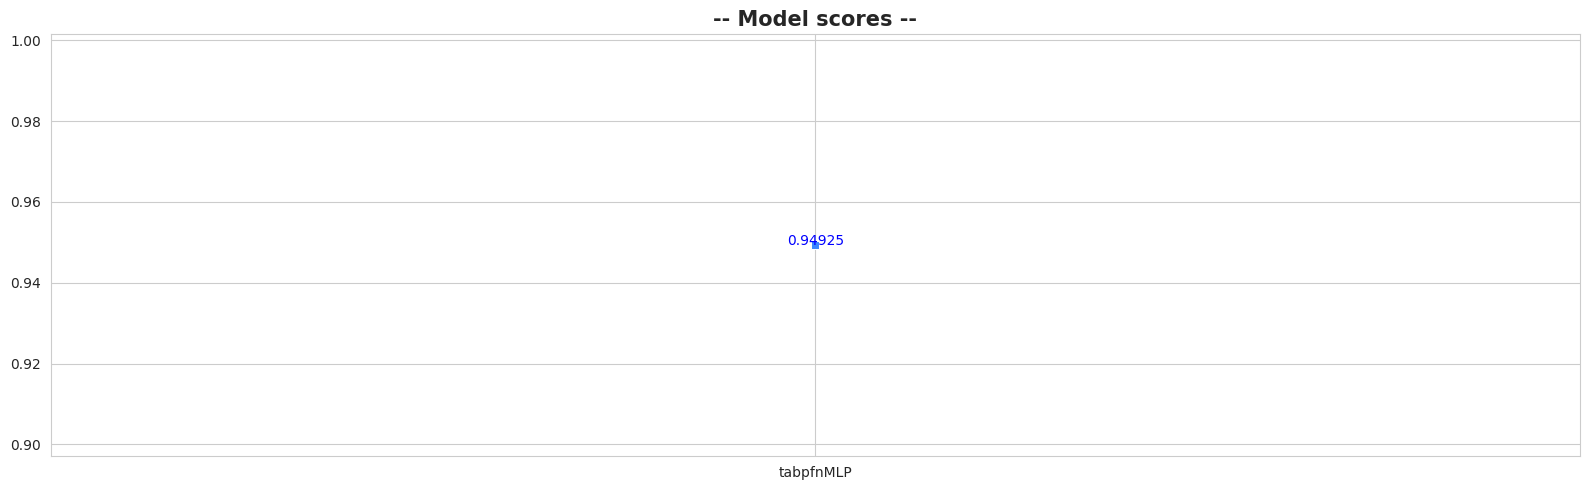

In [22]:
all_model_scores = {}

for i, (k, v) in enumerate(all_model_predictions.items()):
    for x, z in v.items():
        if x == 'scores':
            all_model_scores[k] = z

raw_scores, calib_scores, names = [], [], []

for k, group in all_model_scores.items():
    raw_scores.append(group)
    names.append(k)

plt.figure(figsize=(16, 5))
ax1 = sns.lineplot(raw_scores, marker='s')

for i, s1 in enumerate(raw_scores):
    ax1.text(float(i), s1+1e-4, s1, ha='center', va='baseline', color='b')

# plt.ylim((0.97, 0.99))
# plt.legend(loc='best')
plt.xticks(range(len(names)), names, rotation=0)
plt.title('-- Model scores --', fontdict={'weight': 'semibold', 'size': 15})

plt.tight_layout()
plt.show()

In [23]:
all_model_predictions.keys()

dict_keys(['tabpfnMLP'])

In [24]:
## -- Get OOF predictions --
for i, (k, v) in enumerate(all_model_predictions.items()):
    for x, z in v.items():
        if x == 'oof_preds':
            ## -- Create base submission file --
            n = f"{k}_{str(raw_scores[i]).split('.')[1]}"
            np.save(f"oof_pytab_{n}_.npy", z)
            print(f'{n} oof saved!')

            # ## -- Create calib submission file --
            # cal_n = f"{k}_{str(calib_scores[i]).split('.')[1]}"
            # np.save(f"oof_calib_{cal_n}_.npy", z[1])
            # print(f'OOF file for calibrated model saved!')

            print()

tabpfnMLP_94925 oof saved!



Submission tabpfnMLP_94925 saved! (295753,)


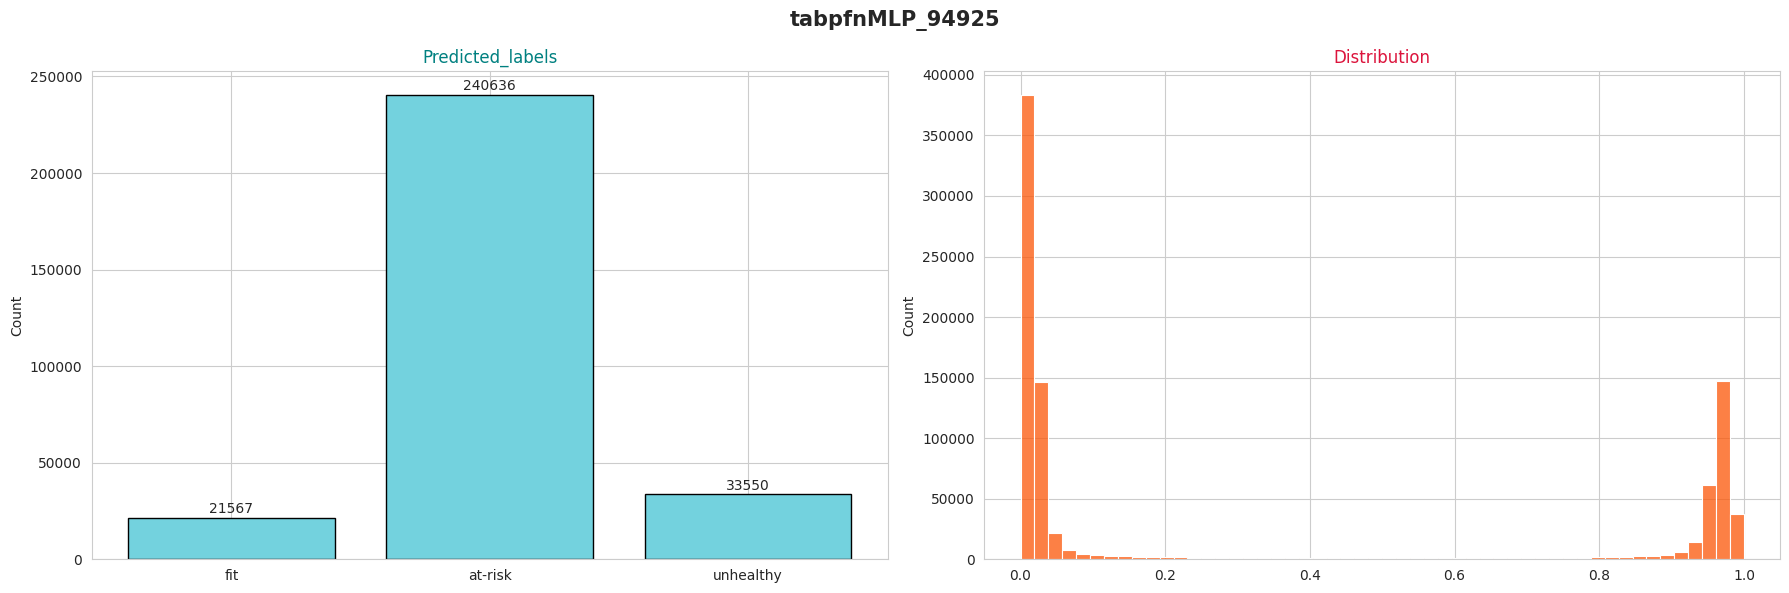

In [25]:
## -- Get TEST predictions/submissions --
for i, (k, v) in enumerate(all_model_predictions.items()):
    for j, (x, z) in enumerate(v.items()):
        if x == 'test_preds':
            ## -- Base submission file --
            n = f"{k}_{str(raw_scores[i]).split('.')[1]}"
            np.save(f"test_pytab_{n}_.npy", z)
            
            base_preds = np.argmax(z, axis=1)
            submit[TARGET] = pd.Series(base_preds).map(r_mapping)
            submit.to_csv(f'submit_pytab_{n}.csv', index=False)
            print(f'Submission {n} saved! {base_preds.shape}')

            # ## -- Calib submission file --
            # cal_n = f"{k}_{str(calib_scores[i]).split('.')[1]}"
            # np.save(f"test_calib_{cal_n}_.npy", y[1])
            
            # calib_preds = np.argmax(y[1], axis=1)
            # submit[TARGET] = pd.Series(calib_preds).map(r_mapping)
            # submit.to_csv(f'submit_calib_{cal_n}_.csv', index=False)
            # print(f'Submission calib TEST file saved! {calib_preds.shape}')

            counts = [np.sum(base_preds == _) for _ in range(len(np.unique(base_preds)))]

            fig, axs = plt.subplots(1, 2, figsize=(18, 6))
            axs[0].bar([*mapping.keys()], counts, color='#73D2DE', edgecolor='k')
            axs[0].set_title("Predicted_labels", color='teal')
            axs[0].set_ylabel('Count')

            for i, c in enumerate(counts):
                axs[0].text(i, c+2500, str(c), ha='center', fontsize=10)

            sns.histplot(z.ravel(), ax=axs[1], color='#FB5607')
            axs[1].set_title("Distribution", color='crimson')
            
            plt.suptitle(n, fontsize=15, fontweight='semibold')
            
            plt.tight_layout()
            plt.show()

            print()

In [26]:
# !rm -r /kaggle/working